# Credit Decision Engine

---

Author: José Reyes

Probability of Default Modeling

**Difficulty**

🟡 Intermediate

**Estimated Reading Time**

45–60 minutes

**Prerequisites**

- Notebook 01 — Credit Scoring Fundamentals
- Notebook 02 — Building an Educational Credit Score
- Notebook 03 — Probability of Default
- Notebook 04 - Portfolio Risk Simulation

---

How do financial institutions transform
Credit Risk into Lending Decisions?

More importantly...

How did banks evolve from manually written business rules to Machine Learning models?

## 1. Learning Objectives

After completing this notebook you will be able to:

- Explain how banks transform risk measurements into lending decisions.

- Understand the role of Business Rules inside a Credit Decision Engine.

- Build a simplified Rule-Based Decision Engine.

- Assign interest rates according to customer risk.

- Assign educational credit limits.

- Understand the limitations of manually written rules.

- Explain why Machine Learning became necessary in modern banking.

- Train a Decision Tree that learns the same approval policy.

- Compare Rule-Based Systems with Machine Learning.

## 2. Business Context

In the previous notebooks we built a simplified credit risk pipeline.

We learned how to estimate a customer's Credit Score and Probability of Default (PD).

However...

Measuring risk is not the final objective.

Banks must eventually decide:

- Should we approve this customer?
- Should we reject the application?
- Should we send it to a credit analyst?
- What interest rate should we charge?
- How much money are we willing to lend?

This decision process is commonly known as a **Credit Decision Engine**.

Historically, banks solved this problem using manually written business rules.

Today, these rule-based systems coexist with Machine Learning models capable of learning complex patterns from millions of historical observations.

In this notebook we will build both approaches and understand how one evolved into the other.

## 3. Loading our Credit Portfolio

Instead of creating new customers, we will continue working with the portfolio generated in the previous notebook.

This simulates how analytics teams usually receive data generated by previous stages in a production environment.

In [1]:
import pandas as pd

from graphviz import Digraph

from src.approval_engine import generate_decision
from src.pricing import assign_interest_rate
from src.credit_limit import assign_credit_limit

### 3.1 Credit Decision Workflow

Before writing code, let's understand the complete business process.

The portfolio we generated in the previous notebook already contains each customer's Credit Score and Probability of Default.

Now our goal is to transform those risk metrics into lending decisions.

```mermaid
flowchart TD

    A["Customer Portfolio"] --> B["Credit Score<br/>Probability of Default"]

    B --> C["Business Rules"]

    C --> D["Credit Decision Engine"]

    D --> E["Approved"]
    D --> F["Rejected"]
    D --> G["Manual Review"]

    E --> H["Interest Rate"]
    G --> H

    H --> I["Credit Limit"]
```

## 4. Loading our Credit Portfolio

Instead of creating new customers, we will continue working with the portfolio generated in the previous notebook.

This simulates how analytics teams usually receive data generated by previous stages in a production environment.

In [2]:
customers = pd.read_csv("../data/customers.csv")
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low


## 6. Portfolio Overview

In [3]:
customers.info()
customers.describe()
customers.head()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             500 non-null    str    
 1   Late_Payments           500 non-null    int64  
 2   Credit_Utilization      500 non-null    float64
 3   Credit_History_Years    500 non-null    int64  
 4   Credit_Mix              500 non-null    int64  
 5   Recent_Inquiries        500 non-null    int64  
 6   Raw_Score               500 non-null    float64
 7   Credit_Score            500 non-null    int64  
 8   Probability_of_Default  500 non-null    float64
 9   Risk_Category           500 non-null    str    
dtypes: float64(3), int64(5), str(2)
memory usage: 39.2 KB


,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low


## 7. Applying Business Rules

Our first approach uses manually defined lending policies.

Although simple, this strategy has been used for decades and remains an important component of modern credit systems.

In [4]:
# Caling the generate_decision function which gathers each function to approve or deny, and returns a dictionary for both new cells
customers[["Decision", "Decision_Reason"]] = customers.apply(generate_decision, axis=1)

customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low,Approved,Customer satisfies approval policy.
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium,Approved,Customer satisfies approval policy.
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low,Approved,Customer satisfies approval policy.
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low,Approved,Customer satisfies approval policy.


In [5]:
# Lets filter 2 Rejected ones just to see
customers[customers["Decision"] != "Approved"].head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.
11,C0012,4,69.37,10,1,0,51.00,630,0.344944,High,Manual Review,Intermediate risk requires manual review.
34,C0035,4,82.09,13,2,3,41.50,587,0.457011,High,Manual Review,Credit Score below minimum policy.
35,C0036,2,76.60,5,1,2,57.25,658,0.314061,High,Manual Review,Intermediate risk requires manual review.
50,C0051,4,74.32,5,1,1,39.50,578,0.469478,High,Manual Review,Credit Score below minimum policy.


Each customer has now received a lending decision based on the institution's credit policy.

Notice that no Machine Learning model has been used.

Every decision follows explicitly programmed business rules.

## 8. Assigning Interest Rates

In [6]:
customers[["Interest_Rate", "Pricing_Tier"]] = customers.apply(assign_interest_rate, axis=1)

customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason,Interest_Rate,Pricing_Tier
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium,Approved,Customer satisfies approval policy.,0.13,Moderate Risk
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low,Approved,Customer satisfies approval policy.,0.09,Very Low Risk


In [7]:
# Lets filter again for rejected ones just to test
customers[customers["Decision"] != "Approved"].head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason,Interest_Rate,Pricing_Tier
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk
11,C0012,4,69.37,10,1,0,51.00,630,0.344944,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk
34,C0035,4,82.09,13,2,3,41.50,587,0.457011,High,Manual Review,Credit Score below minimum policy.,0.24,Manual Review
35,C0036,2,76.60,5,1,2,57.25,658,0.314061,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk
50,C0051,4,74.32,5,1,1,39.50,578,0.469478,High,Manual Review,Credit Score below minimum policy.,0.24,Manual Review


The interest rate represents the price of risk.

Customers with lower Probability of Default receive lower rates, while riskier customers receive more expensive loans.

## 9. Assigning Credit Limits

In [8]:
customers[["Credit_Limit", "Credit_Tier"]] = customers.apply(assign_credit_limit, axis=1)

In [9]:
customers

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason,Interest_Rate,Pricing_Tier,Credit_Limit,Credit_Tier
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk,350000,Very Good
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk,75000,Limited
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium,Approved,Customer satisfies approval policy.,0.13,Moderate Risk,250000,Good
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk,350000,Very Good
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low,Approved,Customer satisfies approval policy.,0.09,Very Low Risk,500000,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,0,35.44,7,2,2,84.50,780,0.065861,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk,350000,Very Good
496,C0497,1,36.19,18,2,5,79.50,758,0.098983,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk,350000,Very Good
497,C0498,0,63.79,7,1,2,76.50,744,0.120069,Low,Approved,Customer satisfies approval policy.,0.13,Moderate Risk,250000,Good
498,C0499,4,57.27,12,1,3,50.00,625,0.396723,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk,75000,Limited


In [10]:
# Lets filter again for rejected ones just to test
customers[customers["Decision"] != "Approved"].head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason,Interest_Rate,Pricing_Tier,Credit_Limit,Credit_Tier
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk,75000,Limited
11,C0012,4,69.37,10,1,0,51.00,630,0.344944,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk,75000,Limited
34,C0035,4,82.09,13,2,3,41.50,587,0.457011,High,Manual Review,Credit Score below minimum policy.,0.24,Manual Review,75000,Limited
35,C0036,2,76.60,5,1,2,57.25,658,0.314061,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk,150000,Fair
50,C0051,4,74.32,5,1,1,39.50,578,0.469478,High,Manual Review,Credit Score below minimum policy.,0.24,Manual Review,75000,Limited


Once the institution decides to lend, it must determine the maximum exposure it is willing to accept.

In this simplified example, Credit Score determines the customer's maximum credit limit.

## 10. Portfolio after Decision Engine

In [11]:
customers.head()

,Customer_ID,Late_Payments,Credit_Utilization,Credit_History_Years,Credit_Mix,Recent_Inquiries,Raw_Score,Credit_Score,Probability_of_Default,Risk_Category,Decision,Decision_Reason,Interest_Rate,Pricing_Tier,Credit_Limit,Credit_Tier
0,C0001,0,51.15,11,3,4,79.00,756,0.086329,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk,350000,Very Good
1,C0002,4,78.77,8,3,0,44.50,600,0.338018,High,Manual Review,Intermediate risk requires manual review.,0.20,Very High Risk,75000,Limited
2,C0003,2,62.11,11,1,1,72.25,725,0.179164,Medium,Approved,Customer satisfies approval policy.,0.13,Moderate Risk,250000,Good
3,C0004,1,34.62,13,2,0,86.50,789,0.052808,Low,Approved,Customer satisfies approval policy.,0.11,Low Risk,350000,Very Good
4,C0005,0,28.83,12,1,1,93.00,818,0.045172,Very Low,Approved,Customer satisfies approval policy.,0.09,Very Low Risk,500000,Excellent


## 11. Visualizing the Decision Engine

The following diagram summarizes the simplified lending policy implemented in our Python modules.

```mermaid
flowchart TD

    A{"Credit Score ≥ 600?"}

    A -- No --> B["Rejected"]

    A -- Yes --> C{"PD ≤ 30%?"}

    C -- Yes --> D["Approved"]

    C -- No --> E{"PD ≤ 50%?"}

    E -- Yes --> F["Manual Review"]

    E -- No --> G["Rejected"]
```

## 12. Why Business Rules Are Not Enough

Imagine a bank serving 20 million customers.

Can we manually write thousands of rules?

Probably not.

As institutions grow, rule-based systems become increasingly difficult to maintain.

This challenge motivated the adoption of Machine Learning models capable of learning patterns directly from historical data.

```mermaid
flowchart LR

    A["Business Rules"]
        --> B["Historical Lending Decisions"]

    B --> C["Training Dataset"]

    C --> D["Decision Tree Classifier"]

    D --> E["Learned Lending Policy"]

    E --> F["Future Credit Decisions"]
```

### 12.1 Rule-Based Systems vs Machine Learning

| Business Rules                 | Machine Learning              |
| ------------------------------ | ----------------------------- |
| Written by humans              | Learned from data             |
| Easy to explain                | More difficult to explain     |
| Manual maintenance             | Model retraining              |
| Works well for simple policies | Handles complex relationships |
| Still widely used              | Increasingly common           |


## 13. From Rules to ML

### 13.1 Preparing the Dataset

The decisions generated by our rule engine will now become the labels used to train a Machine Learning model.

Our objective is not to predict real defaults.

Instead, we want the model to learn our simplified lending policy.

In [12]:
X = customers[["Credit_Score","Probability_of_Default"]]
y = customers["Decision"]

### 13.2 Training Our First Decision Tree

In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

[Text(0.5, 0.75, 'Probability_of_Default <= 0.302\ngini = 0.069\nsamples = 500\nvalue = [482, 18]\nclass = Approved'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 482\nvalue = [482, 0]\nclass = Approved'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]\nclass = Manual Review'),
 Text(0.625, 0.5, '  False')]

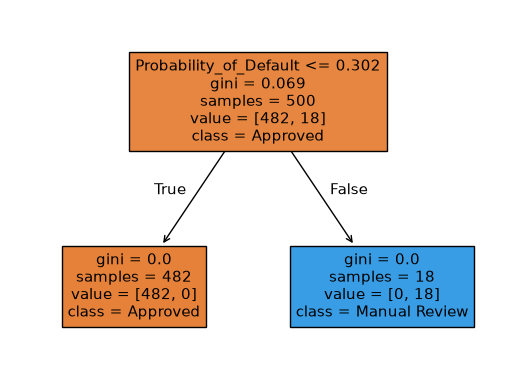

In [14]:
from sklearn.tree import plot_tree

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

Notice something remarkable.

The Decision Tree discovered almost the same logic we originally programmed by hand.

This is the essence of supervised learning.

Instead of writing rules ourselves, we allow the algorithm to infer them from historical examples.

## 14. Business Question

How did our lending policy affect the
overall credit portfolio?

### 14.1 KPI: Approval Rate

In [15]:
approval_rate = (customers["Decision"].eq("Approved").mean() * 100)
print(f"Approval Rate: {approval_rate:.2f}%")

Approval Rate: 96.40%


### 14.2 KPI: Rejection Rate

In [16]:
rejection_rate = (customers["Decision"].eq("Rejected").mean() * 100)
print(f"Rejection Rate: {rejection_rate:.2f}%")

Rejection Rate: 0.00%


### 14.3 KPI: Manual Review Rate

In [17]:
manual_review_rate = (customers["Decision"].eq("Manual Review").mean() * 100)
print(f"Manual Review Rate: {manual_review_rate:.2f}%")

Manual Review Rate: 3.60%


#### 14.3 KPI: Average Interest Rate

In [18]:
average_rate = (customers.query("Decision == 'Approved'")["Interest_Rate"].mean())
print(f"Average Interest Rate: {average_rate:.2f}%")

Average Interest Rate: 0.12%


#### 14.4 KPI: Average Credit Limit

In [19]:
average_limit = (customers.query("Decision == 'Approved'")["Credit_Limit"].mean())
print(f"${average_limit:,.0f}")

$330,446


#### 14.5 KPI: Total Approved Credit

In [20]:
portfolio_exposure = (customers.query("Decision == 'Approved'")["Credit_Limit"].sum())
print(f"${portfolio_exposure:,.0f}")

$159,275,000


#### 14.6 KPI: Decision Distribution

In [21]:
customers["Decision"].value_counts()

Decision
Approved         482
Manual Review     18
Name: count, dtype: int64

#### 14.7 KPI: Credit Tier Distribution

In [22]:
customers["Credit_Tier"].value_counts()

Credit_Tier
Very Good    244
Good         102
Excellent     81
Fair          55
Limited       18
Name: count, dtype: int64

#### 14.8 Decision Distribution Graph

<Axes: xlabel='Decision'>

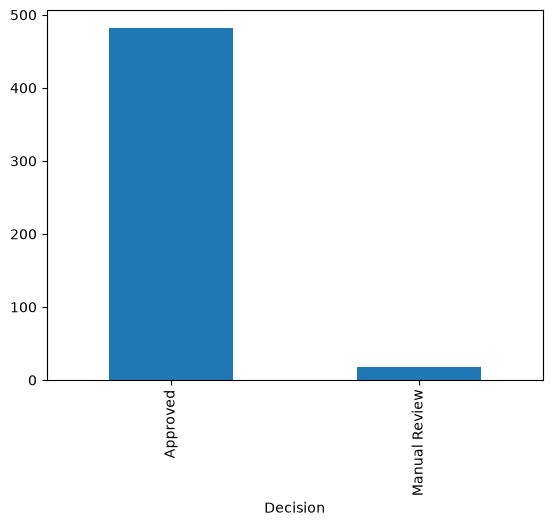

In [23]:
customers["Decision"].value_counts().plot(kind="bar")

#### 14.9 Credit Tier

<Axes: xlabel='Credit_Tier'>

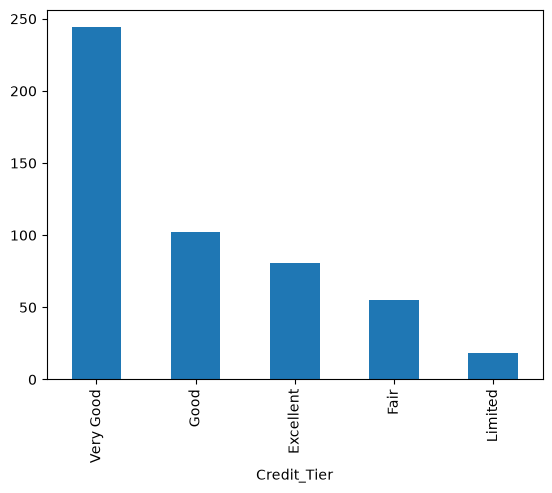

In [24]:
customers["Credit_Tier"].value_counts().plot(kind="bar")

#### 14.10 Interest Rate Distribution

<Axes: >

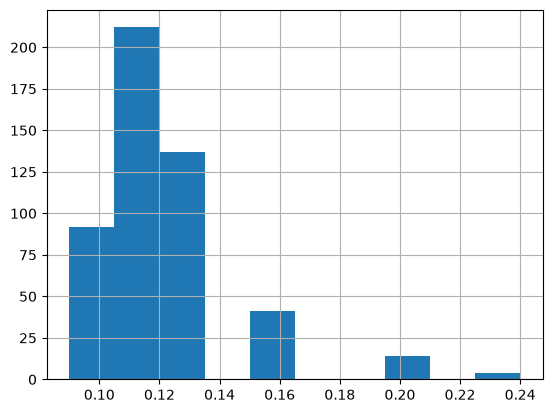

In [25]:
customers["Interest_Rate"].hist()

#### 14.11 Interest Rate Distribution

<Axes: >

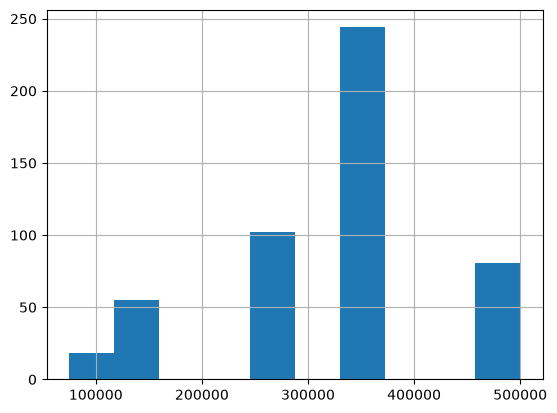

In [26]:
customers["Credit_Limit"].hist()

## 15. Executive Summary

In this notebook we built a simplified Credit Decision Engine.

We transformed:

- Credit Scores

- Probability of Default

into:

- Lending Decisions

- Interest Rates

- Credit Limits

We then demonstrated how Machine Learning can learn these same policies automatically using a Decision Tree.

Although real financial institutions employ much more sophisticated models, the workflow presented here closely resembles the evolution of modern credit risk systems.